# Modelo Preditivo de Risco Educacional — TerraJourney

Este notebook apresenta o pipeline final de preparação dos dados, construção da variável-alvo, treinamento, validação e interpretação do modelo de Machine Learning desenvolvido para identificar estudantes com maior probabilidade de risco educacional.

O fluxo foi consolidado para manter apenas as análises necessárias à justificativa metodológica e à avaliação do modelo final.

## 1. Bibliotecas

Todas as dependências utilizadas no notebook estão centralizadas nesta seção.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
# Paleta de cores do projeto
cores_projeto = ['#2A5C43', '#C4A052', '#8BA891']
COR_PRIMARIA = '#2A5C43'
COR_DESTAQUE = '#C4A052'
COR_SECUNDARIA = '#8BA891'


## 2. Carregamento e organização da base

A base consolidada é carregada diretamente do repositório do projeto. Os registros são ordenados por aluno (`RA`) e ano de referência para permitir a construção das informações temporais utilizadas na definição do risco.

In [2]:
github = (
    'https://raw.githubusercontent.com/andersonserrico/'
    'Datathon_TerraJourney_Grupo48/main/dados/'
    'PEDE_Dados_Unificados.csv'
)

df = pd.read_csv(
    github,
    sep=',',
    encoding='utf-8-sig'
)

df = df.sort_values(
    ['RA', 'Ano_Referencia']
).reset_index(drop=True)

print('Dimensão da base:', df.shape)

Dimensão da base: (3030, 36)


## 3. Construção da variável de risco

A variável-alvo é construída a partir da trajetória do IAN e da defasagem observada no período. Para cada aluno, são considerados os registros anterior, atual e posterior quando disponíveis.

O `IAN_Medio` é ajustado pela evolução da defasagem. Para alunos com apenas um ano de histórico e cujo ano de ingresso coincide com o ano de referência, é aplicada uma penalização adicional de 2 pontos, representando um possível caso de desistência.

Ao final, o indicador é discretizado em três níveis (`2.5`, `5` e `10`). Os níveis abaixo de `10` são classificados como `RISCO = 1`, enquanto o nível `10` é classificado como `RISCO = 0`.

In [3]:
features_risco = [
    'RA',
    'Ano_Referencia',
    'Ano_Ingresso',
    'Idade',
    'IAN',
    'Defasagem',
    'Pedra'
]

df_risco = (
    df[features_risco]
    .copy()
    .sort_values(['RA', 'Ano_Referencia'])
    .reset_index(drop=True)
)

# Quantidade de anos distintos por aluno
df_risco['Qtd_Anos'] = (
    df_risco.groupby('RA')['Ano_Referencia']
    .transform('nunique')
)

# Indicadores temporais
df_risco['IAN_PASSADO'] = df_risco.groupby('RA')['IAN'].shift(1)
df_risco['IAN_FUTURO'] = df_risco.groupby('RA')['IAN'].shift(-1)

df_risco['IAN_Medio'] = (
    df_risco[['IAN_PASSADO', 'IAN', 'IAN_FUTURO']]
    .mean(axis=1, skipna=True)
)

df_risco['Def_PASSADO'] = df_risco.groupby('RA')['Defasagem'].shift(1)
df_risco['Def_FUTURO'] = df_risco.groupby('RA')['Defasagem'].shift(-1)

df_risco['Def_Periodo'] = (
    df_risco[['Def_PASSADO', 'Defasagem', 'Def_FUTURO']]
    .sum(axis=1, skipna=True)
)

# Ajuste do IAN médio pela trajetória da defasagem
df_risco['IAN_Medio'] = (
    df_risco['IAN_Medio'] + df_risco['Def_Periodo']
)

# Penalização para possível desistência
condicao_desistencia = (
    (df_risco['Qtd_Anos'] == 1)
    & (df_risco['Ano_Ingresso'] == df_risco['Ano_Referencia'])
)

df_risco.loc[condicao_desistencia, 'IAN_Medio'] -= 2

# Discretização do IAN médio ajustado
df_risco['IAN_Medio_ajustado'] = np.select(
    [
        df_risco['IAN_Medio'] <= 3,
        df_risco['IAN_Medio'] <= 7
    ],
    [2.5, 5],
    default=10
)

# Target
df_risco['RISCO'] = np.where(
    df_risco['IAN_Medio_ajustado'] < 10,
    1,
    0
)

print('Distribuição do target:')
print(df_risco['RISCO'].value_counts())
print()
print('Percentual:')
print(df_risco['RISCO'].value_counts(normalize=True).round(3))

Distribuição do target:
RISCO
1    1981
0    1049
Name: count, dtype: int64

Percentual:
RISCO
1    0.654
0    0.346
Name: proportion, dtype: float64


## 4. Preparação da base de Machine Learning

O target e o `IAN_Medio_ajustado` são incorporados à base original por meio da chave composta `RA + Ano_Referencia`.

Para evitar combinações artificiais de indicadores, não é utilizada imputação pela média. Registros com `IAN` disponível, mas sem `INDE` e com ausência em pelo menos um dos demais indicadores, são excluídos. Os casos residuais com `IPP` ausente também são removidos.

In [4]:
df_ml = df.merge(
    df_risco[
        ['RA', 'Ano_Referencia', 'RISCO', 'IAN_Medio_ajustado']
    ],
    on=['RA', 'Ano_Referencia'],
    how='left',
    validate='many_to_one'
)

features = [
    'INDE',
    'IDA',
    'IEG',
    'IPS',
    'IPP',
    'IAA',
    'IPV',
    'Idade',
    'Genero',
    'Instituicao_Ensino'
]

demais_indicadores = [
    'IDA',
    'IEG',
    'IPS',
    'IPP',
    'IAA',
    'IPV'
]

condicao_remover = (
    df_ml['IAN'].notna()
    & df_ml['INDE'].isna()
    & df_ml[demais_indicadores].isna().any(axis=1)
)

df_removidos = df_ml.loc[condicao_remover].copy()
df_ml = df_ml.loc[~condicao_remover].copy()

ml_base = df_ml[features + ['RISCO']].copy()

# Dois registros residuais sem IPP são retirados da base de modelagem
ml_base = ml_base.dropna(subset=['IPP']).copy()

print('Registros removidos pela regra principal:', len(df_removidos))
print('Dimensão final da base:', ml_base.shape)
print()
print('Valores nulos na base final:')
print(ml_base.isna().sum())
print()
print('Distribuição final do target:')
print(ml_base['RISCO'].value_counts(normalize=True).round(3))

Registros removidos pela regra principal: 185
Dimensão final da base: (2843, 11)

Valores nulos na base final:
INDE                  0
IDA                   0
IEG                   0
IPS                   0
IPP                   0
IAA                   0
IPV                   0
Idade                 0
Genero                0
Instituicao_Ensino    0
RISCO                 0
dtype: int64

Distribuição final do target:
RISCO
1    0.689
0    0.311
Name: proportion, dtype: float64


## 5. Análise de correlação

A matriz de correlação é utilizada como diagnóstico exploratório das variáveis numéricas. Correlação linear não deve ser interpretada como causalidade e não substitui a avaliação das relações não lineares capturadas pelos modelos baseados em árvores.

O `IAN` é apresentado apenas nesta análise exploratória e **não é utilizado como feature do modelo**, pois participa diretamente da construção da variável-alvo.

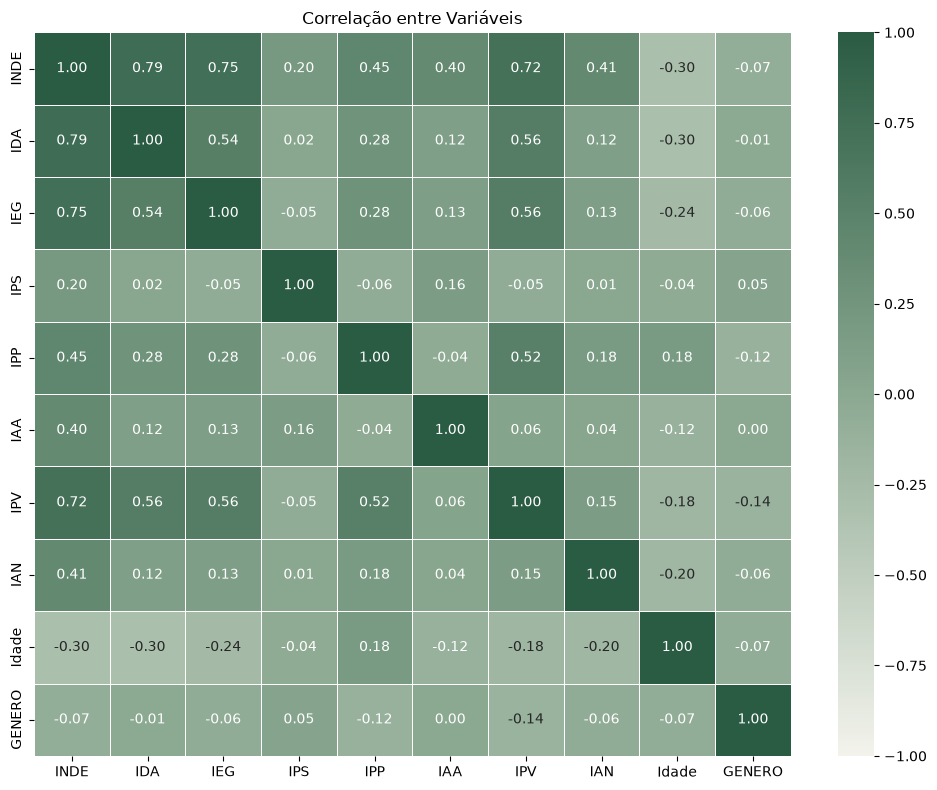

In [5]:
df_corr = df_ml.assign(
    GENERO=df_ml['Genero'].map({'M': 1, 'F': 0})
)

corr_vars = [
    'INDE',
    'IDA',
    'IEG',
    'IPS',
    'IPP',
    'IAA',
    'IPV',
    'IAN',
    'Idade',
    'GENERO'
]

corr = df_corr[corr_vars].corr()

cmap_correlacao = LinearSegmentedColormap.from_list(
    'correlacao_projeto',
    ['#F3F3EC', COR_SECUNDARIA, COR_PRIMARIA]
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=cmap_correlacao,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Correlação entre Variáveis')
plt.tight_layout()
plt.show()

## 6. Separação entre treino e teste

A base é dividida em 70% para treinamento e 30% para teste. O parâmetro `stratify=y` preserva a proporção das classes nos dois conjuntos, enquanto `random_state=42` garante reprodutibilidade.

In [6]:
X = ml_base[features]
y = ml_base['RISCO']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
    shuffle=True
)

print('Distribuição Treino:')
print(y_train.value_counts(normalize=True).round(3))

print()
print('Distribuição Teste:')
print(y_test.value_counts(normalize=True).round(3))

Distribuição Treino:
RISCO
1    0.689
0    0.311
Name: proportion, dtype: float64

Distribuição Teste:
RISCO
1    0.689
0    0.311
Name: proportion, dtype: float64


## 7. Pré-processamento

As variáveis numéricas são processadas com `RobustScaler`. As variáveis categóricas (`Genero` e `Instituicao_Ensino`) são convertidas com `OneHotEncoder`, incluindo tratamento para categorias não observadas no treinamento.

O pré-processamento é incorporado ao `Pipeline`, garantindo que as mesmas transformações sejam aplicadas durante treinamento e inferência.

In [7]:
colunas_numericas = X.select_dtypes(
    include=['number', 'bool']
).columns.tolist()

colunas_categoricas = X.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        (
            'num',
            RobustScaler(),
            colunas_numericas
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            colunas_categoricas
        )
    ]
)

print('Colunas numéricas:', colunas_numericas)
print('Colunas categóricas:', colunas_categoricas)

Colunas numéricas: ['INDE', 'IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IPV', 'Idade']
Colunas categóricas: ['Genero', 'Instituicao_Ensino']


## 8. Comparação dos modelos com Cross-Validation

São comparados Random Forest e Gradient Boosting utilizando validação cruzada com 5 folds. O Gradient Boosting utiliza `min_samples_leaf=20` como regularização para reduzir a criação de regras baseadas em grupos muito pequenos de observações.

As métricas avaliadas são Accuracy, Precision, Recall, F1 Score e ROC AUC. Para o objetivo do projeto, o Recall recebe atenção especial, pois representa a capacidade de identificar estudantes que efetivamente pertencem à classe de risco.

In [8]:
modelo_rf = Pipeline([
    ('preprocessor', preprocessador),
    (
        'classifier',
        RandomForestClassifier(
            n_estimators=500,
            max_depth=12,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        )
    )
])

modelo_gb = Pipeline([
    ('preprocessor', preprocessador),
    (
        'classifier',
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            min_samples_leaf=20,
            random_state=42
        )
    )
])

modelos_cv = {
    'Random Forest': modelo_rf,
    'Gradient Boosting - leaf 20': modelo_gb
}

metricas = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

resultados_cv = []

for nome, modelo in modelos_cv.items():
    cv = cross_validate(
        estimator=modelo,
        X=X_train,
        y=y_train,
        cv=5,
        scoring=metricas,
        n_jobs=-1
    )

    resultados_cv.append({
        'Modelo': nome,
        'Accuracy': cv['test_accuracy'].mean(),
        'Accuracy STD': cv['test_accuracy'].std(),
        'Precision': cv['test_precision'].mean(),
        'Precision STD': cv['test_precision'].std(),
        'Recall': cv['test_recall'].mean(),
        'Recall STD': cv['test_recall'].std(),
        'F1 Score': cv['test_f1'].mean(),
        'F1 Score STD': cv['test_f1'].std(),
        'ROC AUC': cv['test_roc_auc'].mean(),
        'ROC AUC STD': cv['test_roc_auc'].std()
    })

df_cv = (
    pd.DataFrame(resultados_cv)
    .sort_values('ROC AUC', ascending=False)
    .reset_index(drop=True)
)

display(df_cv.round(4))

,Modelo,Accuracy,Accuracy STD,Precision,Precision STD,Recall,Recall STD,F1 Score,F1 Score STD,ROC AUC,ROC AUC STD
0,Gradient Boosting - leaf 20,0.8261,0.0097,0.8415,0.0160,0.9220,0.0203,0.8796,0.0068,0.894,0.0123
1,Random Forest,0.8025,0.0124,0.8677,0.0163,0.8425,0.0239,0.8545,0.0102,0.865,0.0119


## 9. Treinamento e avaliação do melhor modelo

O modelo com melhor desempenho na validação cruzada é treinado novamente utilizando todo o conjunto de treino e avaliado uma única vez no conjunto de teste.

Na configuração final, o Gradient Boosting apresentou desempenho consistente entre Cross-Validation e teste, com destaque para o Recall, mantendo elevada capacidade de identificação dos casos de risco.

In [9]:
nome_melhor_modelo = df_cv.loc[0, 'Modelo']
melhor_modelo = modelos_cv[nome_melhor_modelo]

melhor_modelo.fit(X_train, y_train)

pred = melhor_modelo.predict(X_test)
prob = melhor_modelo.predict_proba(X_test)[:, 1]

print('Melhor modelo:', nome_melhor_modelo)
print('Accuracy :', round(accuracy_score(y_test, pred), 4))
print('Precision:', round(precision_score(y_test, pred), 4))
print('Recall   :', round(recall_score(y_test, pred), 4))
print('F1 Score :', round(f1_score(y_test, pred), 4))
print('ROC AUC  :', round(roc_auc_score(y_test, prob), 4))

Melhor modelo: Gradient Boosting - leaf 20
Accuracy : 0.8206
Precision: 0.8393
Recall   : 0.915
F1 Score : 0.8755
ROC AUC  : 0.8841


### Interpretação das métricas finais

O modelo final apresentou **Accuracy de aproximadamente 82%**, **Precision de 84%**, **Recall de 91,5%**, **F1 Score de 87,6%** e **ROC AUC de 88,4%** no conjunto de teste.

O Recall é especialmente relevante para a aplicação: o modelo consegue identificar a grande maioria dos estudantes classificados como em risco. Nesse contexto, um falso negativo — deixar de sinalizar um estudante realmente em risco — tende a ser mais crítico do que um falso positivo, que representa um caso adicional para acompanhamento.

As métricas do conjunto de teste permaneceram próximas às médias obtidas na validação cruzada, indicando boa capacidade de generalização.

## 10. Matriz de confusão

A matriz de confusão permite visualizar os acertos e erros por classe, destacando especialmente os falsos negativos (`Risco` previsto como `Sem Risco`).

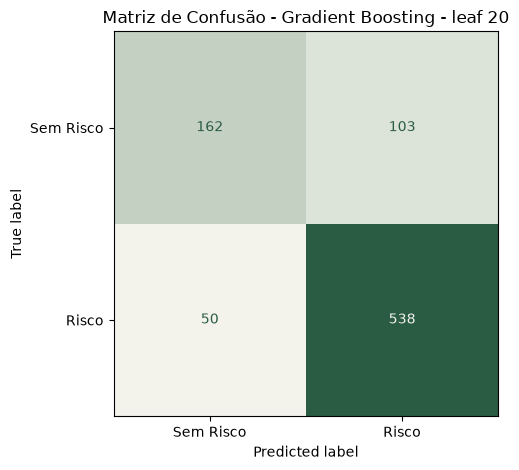

In [10]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sem Risco', 'Risco']
)

disp.plot(
    values_format='d',
    cmap=LinearSegmentedColormap.from_list(
        'matriz_projeto',
        ['#F3F3EC', COR_SECUNDARIA, COR_PRIMARIA]
    ),
    colorbar=False
)
plt.title(f'Matriz de Confusão - {nome_melhor_modelo}')
plt.tight_layout()
plt.show()

## 11. Importância das variáveis

A importância das variáveis indica quanto cada feature contribuiu para as decisões das árvores do modelo. Esses valores **não representam causalidade nem direção do efeito**; mostram apenas a contribuição relativa para a capacidade preditiva do Gradient Boosting.

O INDE tende a se destacar por sintetizar múltiplas dimensões do desenvolvimento educacional. O IAN não é utilizado diretamente como feature do modelo, embora represente 10% da composição do INDE.

,Variavel,Importancia
0,num__INDE,0.4438
1,num__IDA,0.1433
2,num__Idade,0.0921
3,num__IEG,0.0669
4,num__IPS,0.0584
5,num__IPV,0.0582
6,num__IAA,0.0522
7,num__IPP,0.0370
8,cat__Instituicao_Ensino_Bolsista,0.0251
9,cat__Instituicao_Ensino_Publica,0.0229


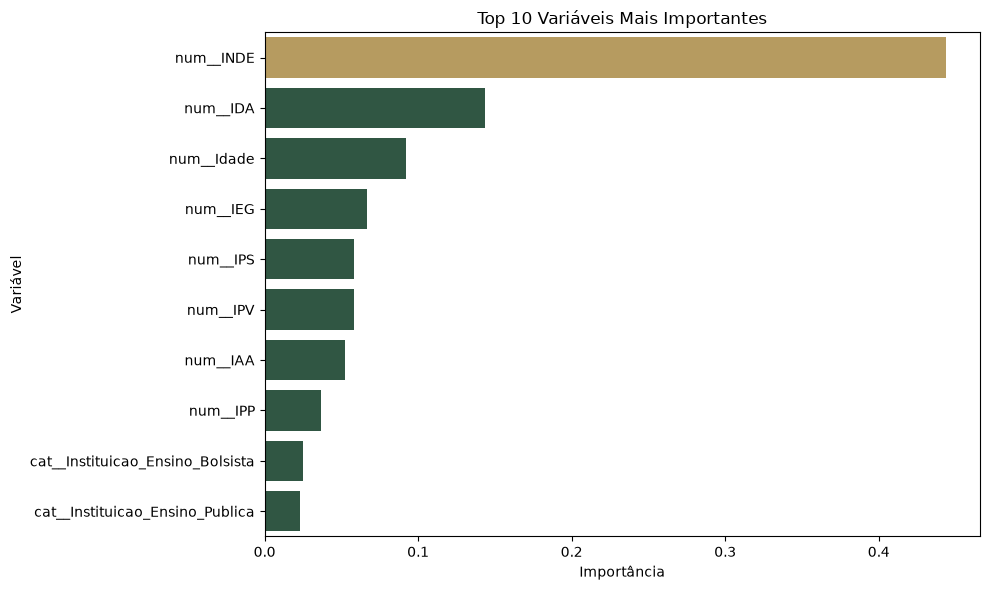

In [11]:
preprocessor = melhor_modelo.named_steps['preprocessor']
classificador = melhor_modelo.named_steps['classifier']

nomes_features = preprocessor.get_feature_names_out()
importancias = classificador.feature_importances_

fi = pd.DataFrame({
    'Variavel': nomes_features,
    'Importancia': importancias
}).sort_values(
    'Importancia',
    ascending=False
).reset_index(drop=True)

display(fi.round(4))

fi_top10 = fi.head(10).copy()

# A variável de maior importância recebe a cor de destaque do projeto.
cores_importancia = [
    COR_DESTAQUE if i == 0 else COR_PRIMARIA
    for i in range(len(fi_top10))
]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=fi_top10,
    x='Importancia',
    y='Variavel',
    hue='Variavel',
    palette=cores_importancia,
    legend=False
)
plt.title('Top 10 Variáveis Mais Importantes')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

## 12. Ranking de risco na base mais atual

O modelo é aplicado aos registros do ano mais recente que possuem todas as features necessárias. A probabilidade estimada pode ser utilizada como instrumento de priorização para acompanhamento, não como diagnóstico isolado.

In [12]:
base_atual = df[
    df['Ano_Referencia'] == df['Ano_Referencia'].max()
].copy()

base_predicao = base_atual.dropna(
    subset=features
).copy()

base_predicao['PROB_RISCO'] = melhor_modelo.predict_proba(
    base_predicao[features]
)[:, 1]

base_predicao['RISCO_PREDITO'] = melhor_modelo.predict(
    base_predicao[features]
)

top_risco = (
    base_predicao[
        [
            'RA',
            'Idade',
            'Genero',
            'Instituicao_Ensino',
            'INDE',
            'IDA',
            'IEG',
            'IPP',
            'IPV',
            'PROB_RISCO',
            'RISCO_PREDITO'
        ]
    ]
    .sort_values('PROB_RISCO', ascending=False)
)

display(top_risco.head(30))

,RA,Idade,Genero,Instituicao_Ensino,INDE,IDA,IEG,IPP,IPV,PROB_RISCO,RISCO_PREDITO
2722,RA-85,17,M,Publica,6.999509,7.666667,8.668047,6.250000,6.993333,0.974306,1
652,RA-137,18,F,Outros,6.576761,6.833333,7.582973,4.791667,6.276667,0.967981,1
2930,RA-949,9,F,Publica,7.132343,6.500000,8.785714,6.250000,6.495000,0.965159,1
2527,RA-774,10,F,Publica,5.685771,3.750000,6.392857,6.250000,6.405000,0.963912,1
1244,RA-267,17,F,Publica,5.896307,2.000000,8.285534,4.583333,6.273333,0.962866,1
1354,RA-315,15,F,Publica,6.076870,6.833333,5.918519,7.500000,7.627500,0.962468,1
985,RA-164,17,M,Privada,6.837126,5.666667,8.084795,6.250000,6.886667,0.960656,1
957,RA-1616,17,F,Publica,7.147738,6.166667,8.436275,7.187500,7.120000,0.959534,1
899,RA-1570,16,F,Publica,7.894084,8.333333,7.542088,7.750000,8.672500,0.958374,1
888,RA-1562,16,F,Publica,5.458833,0.500000,8.666667,6.250000,6.872500,0.958070,1


## 13. Simulação para um novo aluno

Para novos registros, o INDE é calculado antes da previsão de acordo com a fase do estudante. Até a Fase 7 são utilizados IAN, IDA, IEG, IAA, IPS, IPP e IPV; para a Fase 8, a composição utiliza IAN, IDA, IEG, IAA e IPS com os pesos específicos da metodologia.

A função retorna a probabilidade estimada de `RISCO = 1` utilizando o mesmo Pipeline treinado anteriormente.

In [18]:
def calcular_inde(
    fase,
    ian,
    ida,
    ieg,
    ips,
    ipp,
    iaa,
    ipv
):
    if fase == 'Fase 8':
        return (
            (ian * 0.10)
            + (ida * 0.40)
            + (ieg * 0.20)
            + (iaa * 0.10)
            + (ips * 0.20)
        )

    return (
        (ian * 0.10)
        + (ida * 0.20)
        + (ieg * 0.20)
        + (iaa * 0.10)
        + (ips * 0.10)
        + (ipp * 0.10)
        + (ipv * 0.20)
    )


def prever_risco(
    fase,
    ian,
    ida,
    ieg,
    ips,
    ipp,
    iaa,
    ipv,
    idade,
    genero,
    escola
):
    inde = calcular_inde(
        fase=fase,
        ian=ian,
        ida=ida,
        ieg=ieg,
        ips=ips,
        ipp=ipp,
        iaa=iaa,
        ipv=ipv
    )

    novo_aluno = pd.DataFrame({
        'INDE': [inde],
        'IDA': [ida],
        'IEG': [ieg],
        'IPS': [ips],
        'IPP': [ipp],
        'IAA': [iaa],
        'IPV': [ipv],
        'Idade': [idade],
        'Genero': [genero],
        'Instituicao_Ensino': [escola]
    })

    probabilidade = melhor_modelo.predict_proba(
        novo_aluno
    )[0, 1]

    print(f'INDE calculado: {inde:.2f}')
    print(f'Probabilidade de risco: {probabilidade:.2%}')

    return probabilidade

## Exportação do artefato do modelo para o Streamlit

Nesta etapa, o modelo Random Forest final e os dados necessários para reconstruir as análises no Streamlit são consolidados em um único arquivo `.pkl`. O artefato guarda o modelo treinado, as features esperadas, as importâncias das variáveis, as probabilidades da base de teste e o limiar de classificação. Dessa forma, a aplicação não precisa recalcular o treinamento nem as análises para gerar os gráficos em Plotly.


In [15]:
import joblib
from pathlib import Path


# ---------------------------------------------------------
# Dados de avaliação do melhor modelo
# ---------------------------------------------------------

# As probabilidades da base de teste já foram calculadas anteriormente:
# prob = melhor_modelo.predict_proba(X_test)[:, 1]

probabilidades_teste = prob


# ---------------------------------------------------------
# Importância das features
# ---------------------------------------------------------

# O DataFrame fi já foi criado anteriormente com:
# Variavel | Importancia

feature_importance = (
    fi
    .sort_values(
        'Importancia',
        ascending=True
    )
    .copy()
)


# ---------------------------------------------------------
# Artefato para o Streamlit
# ---------------------------------------------------------

artefato_modelo = {

    # Modelo final escolhido pelo processo de validação
    'modelo': melhor_modelo,

    'nome_modelo': nome_melhor_modelo,

    # Features originais esperadas pelo Pipeline
    'features_modelo': X.columns.tolist(),

    # Dados para gráfico de importância
    'feature_importance': {
        'features': feature_importance['Variavel'].tolist(),
        'importancias': feature_importance['Importancia'].tolist()
    },

    # Dados para gráfico da distribuição de probabilidades
    'avaliacao': {
        'probabilidades_teste': probabilidades_teste.tolist(),
        'limiar_classificacao': 0.50
    }
}


# ---------------------------------------------------------
# Salvar artefato
# ---------------------------------------------------------

pasta_modelo = Path('../modelo')

pasta_modelo.mkdir(
    parents=True,
    exist_ok=True
)

caminho_artefato = (
    pasta_modelo
    / 'modelo_risco.pkl'
)

joblib.dump(
    artefato_modelo,
    caminho_artefato
)


print(
    f'Artefato salvo em: '
    f'{caminho_artefato.resolve()}'
)


Artefato salvo em: /Users/andersonserricodeoliveira/Documents/FIAP Data Analytics/Datathon/modelo/modelo_risco.pkl


In [16]:
# Validação do artefato exportado
artefato_validacao = joblib.load(caminho_artefato)

print('Chaves principais:', artefato_validacao.keys())
print('Features do modelo:', artefato_validacao['features_modelo'])
print('Quantidade de importâncias:', len(artefato_validacao['feature_importance']['features']))
print('Quantidade de probabilidades:', len(artefato_validacao['avaliacao']['probabilidades_teste']))
print('Limiar:', artefato_validacao['avaliacao']['limiar_classificacao'])


Chaves principais: dict_keys(['modelo', 'nome_modelo', 'features_modelo', 'feature_importance', 'avaliacao'])
Features do modelo: ['INDE', 'IDA', 'IEG', 'IPS', 'IPP', 'IAA', 'IPV', 'Idade', 'Genero', 'Instituicao_Ensino']
Quantidade de importâncias: 14
Quantidade de probabilidades: 853
Limiar: 0.5


### Exemplo de uso

O exemplo abaixo demonstra a chamada da função de simulação. Os valores podem ser substituídos pelos indicadores do estudante que se deseja avaliar.

In [17]:
prever_risco(
    fase='Fase 5',
    ian=10,
    ida=6,
    ieg=7,
    ips=5.5,
    ipp=7.75,
    iaa=6.25,
    ipv=8.9,
    idade=11,
    genero='F',
    escola='Publica'
)

INDE calculado: 7.33
Probabilidade de risco: 37.44%


np.float64(0.37435619083973926)

## 14. Conclusão

O Gradient Boosting regularizado foi selecionado por apresentar o melhor equilíbrio entre capacidade discriminativa e identificação dos casos de risco. A validação cruzada e o teste final apresentaram resultados próximos, indicando estabilidade e boa generalização.

O modelo deve ser utilizado como ferramenta de apoio à priorização e ao acompanhamento dos estudantes. A probabilidade estimada complementa a análise dos indicadores educacionais e não substitui a avaliação pedagógica ou psicossocial realizada pela instituição.